In [15]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy import stats
import regions
from grid_strategy import strategies
import pylab as pl
from matplotlib.patches import Polygon
from matplotlib.path import Path
sqgrid = strategies.SquareStrategy()
basepath = '/orange/adamginsburg/jwst/w51/'
filternames =all_filternames = ['F140M', 'F162M', 'F182M', 'F187N', 'F210M', 'F335M', 'F360M', 'F405N', 'F410M', 'F480M', 'F560W', 'F770W', 'F1000W', 'F1280W', 'F2100W']
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}



tables_per_filters ={'f140m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f140m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f162m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f162m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f182m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f182m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f187n': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f187n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f210m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f210m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f335m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f335m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f360m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f360m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f405n': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f405n_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f410m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f410m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f480m': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f480m_nrca_indivexp_merged_dao_after_merger_combined_with_satstars.fits',
                     'f560w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f560w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f770w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f770w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f1000w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1000w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f1280w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f1280w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits',
                     'f2100w': '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/f2100w_nrca_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits'}

def xmatch_plot(
    basetable,
    ref_filter='f140m',
    filternames=filternames,
    maxsep=0.13*u.arcsec,
    obsid='001',
    sel=None,
    axlims=[-0.5, 0.5, -0.5, 0.5],
    alpha=0.01,
    regs=None,
):
    statsd = {}
    fig1 = pl.figure(figsize=(16, 16))
    fig2 = pl.figure(figsize=(16, 16))

    if sel is None:
        sel = np.ones(len(basetable), dtype=bool)
    basetable = basetable[sel]

    basecrds = basetable[f'skycoord_{ref_filter}']
    refhdr = fits.getheader(image_filenames[ref_filter], ext=('SCI', 1))
    refwcs = WCS(refhdr)

    gridspec = sqgrid.get_grid(len(filternames) - 1)
    ii = 0

    # Save F182M polygon-selected coordinates from the matching iteration
    f182m_poly_crds = None

    for filtername in filternames:
        if filtername.lower() == ref_filter.lower():
            continue

        ax = fig1.add_subplot(gridspec[ii])

        thissel = ~basetable[f'flux_fit_{filtername.lower()}'].mask
        crds = basetable[f'skycoord_{filtername.lower()}'][thissel]
        radiff = (crds.ra - basecrds.ra[thissel]).to(u.arcsec)
        decdiff = (crds.dec - basecrds.dec[thissel]).to(u.arcsec)
        sep = basetable[f'sep_{filtername.lower()}'][thissel].quantity.to(u.arcsec)

        ok = (sep < maxsep) & (sep > 0)

        alpha_use = 0.01 if filtername.lower() in [
            'f140m', 'f162m', 'f182m', 'f187n', 'f210m',
            'f335m', 'f360m', 'f405n', 'f410m', 'f480m'
        ] else 0.1

        ax.scatter(radiff, decdiff, marker=',', s=1, alpha=alpha_use)

        if filtername.lower() == 'f182m':
            vertices = [(-0.08, 0.02), (-0.08, 0.04), (-0.05, 0.04), (-0.05, 0.02)]
            polygon1 = Polygon(vertices, closed=True, fill=False, edgecolor='blue', linewidth=2, label='Group 1')
            ax.add_patch(polygon1)

            path1 = Path(vertices)
            idx1 = path1.contains_points(np.column_stack([radiff.value, decdiff.value]))
            f182m_poly_crds = crds[idx1]

        if regs is None:
            ax.scatter(radiff[ok], decdiff[ok], marker=',', s=1, alpha=alpha_use)
        else:
            for reg in regs:
                reg = regions.Regions.read(f'{basepath}/regions_/{reg}')[0]
                match = reg.contains(crds, refwcs)
                ax.scatter(radiff[ok & match], decdiff[ok & match], marker=',', s=1, alpha=alpha_use)

        ax.vlines(np.nanmedian(radiff[ok].value), -0.15, 0.15, color='r', ls='--')
        ax.hlines(np.nanmedian(decdiff[ok].value), -0.15, 0.15, color='r', ls='--')
        ax.axis(axlims)
        rastd = stats.mad_std(radiff[ok].value)
        decstd = stats.mad_std(decdiff[ok].value)
        ax.set_title(f'{filtername}\nRA std: {rastd:.3f}\", Dec std: {decstd:.3f}\"')

        ax2 = fig2.add_subplot(gridspec[ii])
        ax2.hist(sep.value, bins=np.linspace(0, maxsep.to_value(u.arcsec)))
        ax2.set_title(filtername)

        statsd[filtername] = {
            'med': np.median(sep),
            'mad': stats.mad_std(sep.copy()),
            'std': np.std(sep),
            'med_thr': np.median(sep[ok]),
            'mad_thr': stats.mad_std(sep[ok]),
            'std_thr': np.std(sep[ok]),
            '10pct': np.percentile(sep, 10),
            '1pct': np.percentile(sep, 1),
            '0.1pct': np.percentile(sep, 0.1),
            '90pct': np.percentile(sep, 90),
            '99pct': np.percentile(sep, 99),
            '99.9pct': np.percentile(sep, 99.9),
        }
        ii += 1

    fig1.supxlabel('RA Offset (")')
    fig1.supylabel('Dec Offset (")')
    fig2.supxlabel('Offset (")')
    fig1.tight_layout()
    fig2.tight_layout()

    return statsd, f182m_poly_crds

['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

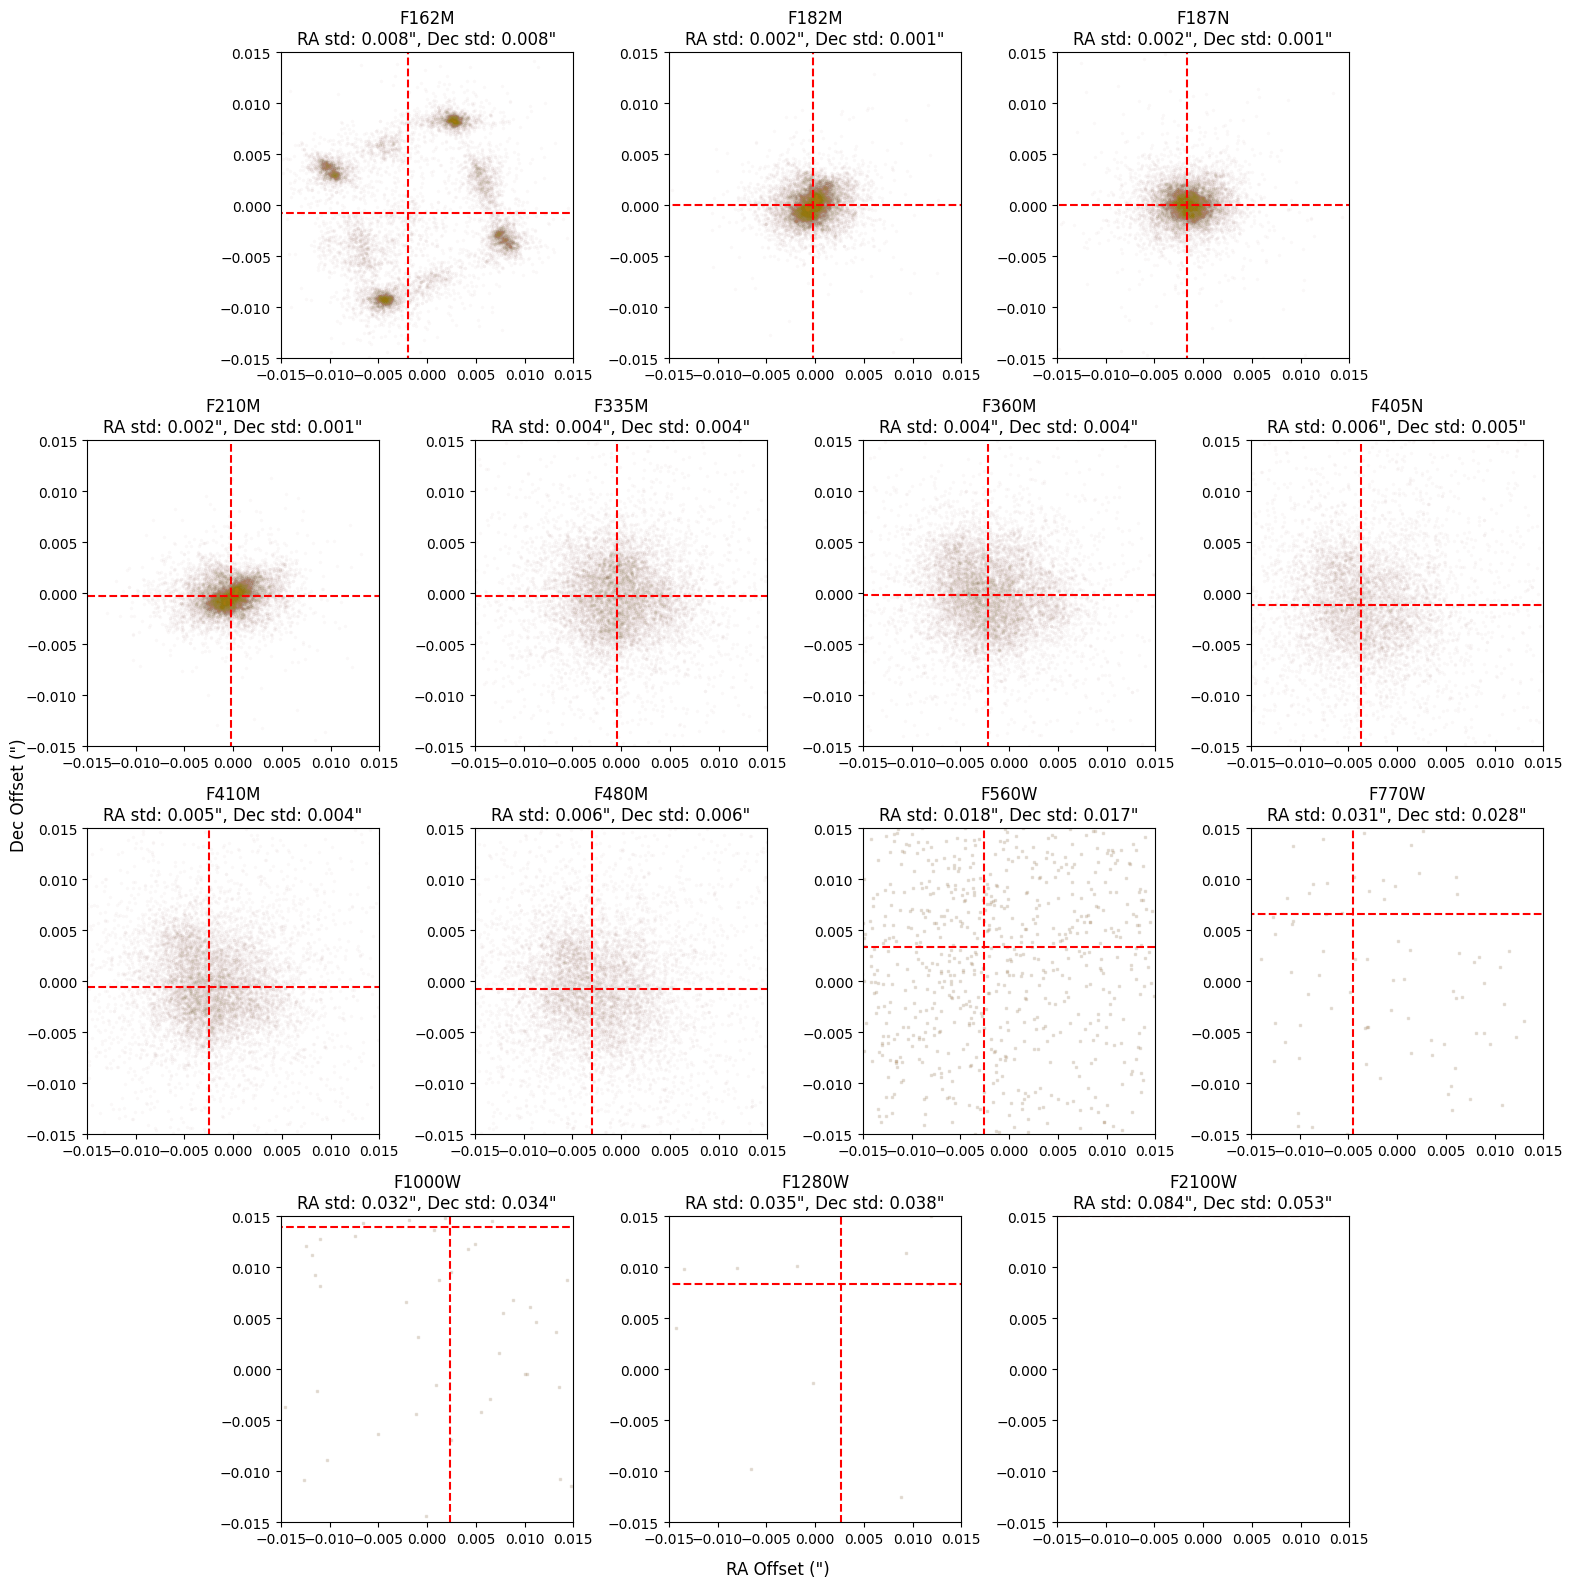

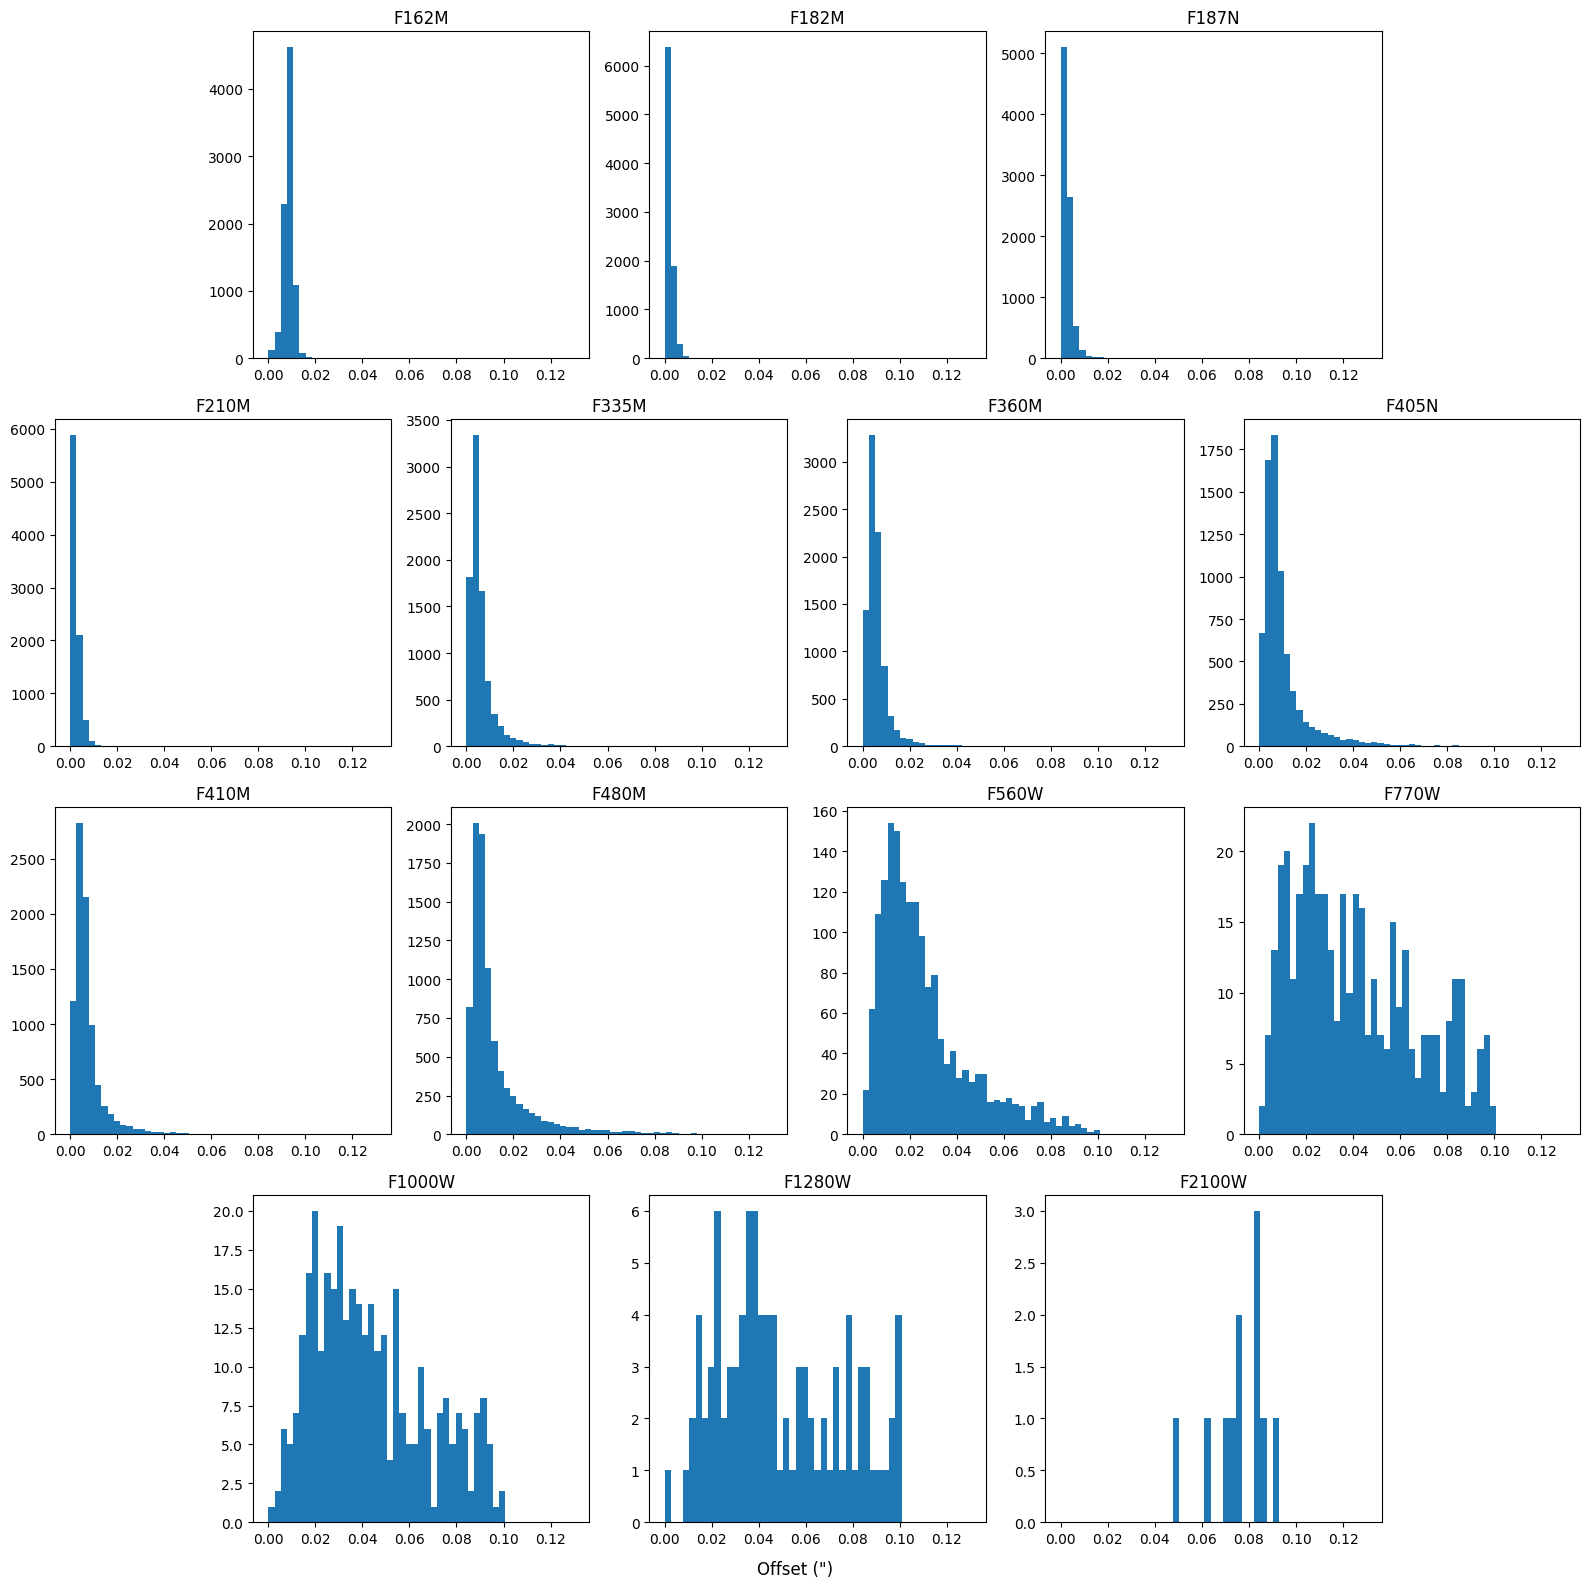

<Figure size 640x480 with 0 Axes>

In [16]:
from astropy.table import Table

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
sel = (catalog['nmatch_bands'] > 3) & (catalog['qfit_f182m'] < 0.8) & (catalog['qfit_f140m'] < 0.8) & (catalog['qfit_f360m'] < 0.8) & (catalog['qfit_f480m'] < 0.8)
print(catalog.colnames)
refined_cat = catalog[sel]
refined_cat.write('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_refined.fits', overwrite=True)
statsd, crds_poly = xmatch_plot(catalog, sel=sel, axlims=[-0.015, 0.015, -0.015, 0.015])

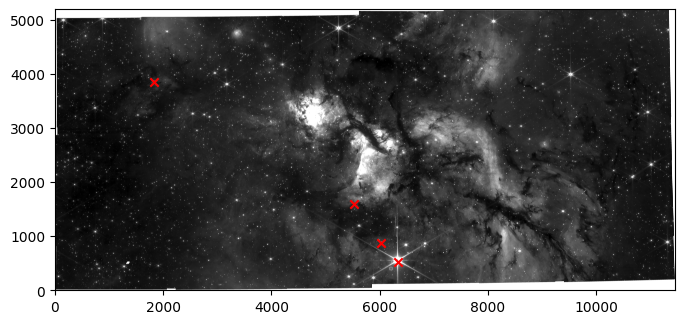

In [17]:
from astropy.io import fits
from astropy.visualization import simple_norm
def load_data(filename):
    fh = fits.open(filename)
    im1 = fh
    data = im1['SCI'].data
    try:
        wht = im1['WHT'].data
    except KeyError:
        wht = None
    err = im1['ERR'].data
    instrument = im1[0].header['INSTRUME']
    telescope = im1[0].header['TELESCOP']
    obsdate = im1[0].header['DATE-OBS']
    return fh, im1, data, wht, err, instrument, telescope, obsdate
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)

fh, im1, data, wht, err, instrument, telescope, obsdate = load_data(image_filenames['f182m'])
norm = simple_norm(data, stretch='sqrt', percent=99)
ax.imshow(data, origin='lower', cmap='gray', norm=norm)

if crds_poly is not None and len(crds_poly) > 0:
    x_poly, y_poly = WCS(im1['SCI'].header).world_to_pixel(crds_poly)
    ax.scatter(x_poly, y_poly, marker='x', color='red', label='Group 1')
    

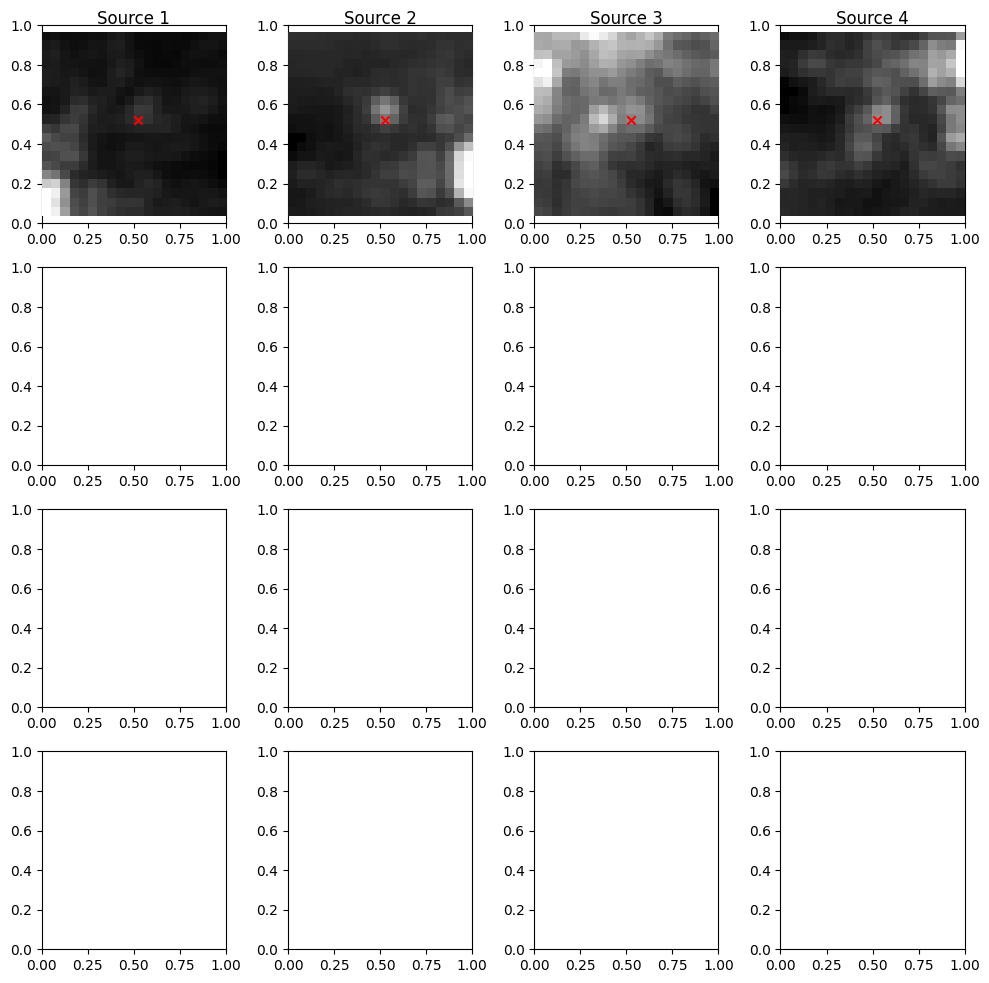

In [18]:
# make snapshots of some sources in the polygon using gridspec
fig2 = plt.figure(figsize=(10, 10))
gs = fig2.add_gridspec(4,4)
ax1 = fig2.add_subplot(gs[0, 0])
ax2 = fig2.add_subplot(gs[0, 1])
ax3 = fig2.add_subplot(gs[0, 2])
ax4 = fig2.add_subplot(gs[0, 3])
ax5 = fig2.add_subplot(gs[1, 0])
ax6 = fig2.add_subplot(gs[1, 1])
ax7 = fig2.add_subplot(gs[1, 2])
ax8 = fig2.add_subplot(gs[1, 3])
ax9 = fig2.add_subplot(gs[2, 0])
ax10 = fig2.add_subplot(gs[2, 1])
ax11 = fig2.add_subplot(gs[2, 2])
ax12 = fig2.add_subplot(gs[2, 3])
ax13 = fig2.add_subplot(gs[3, 0])
ax14 = fig2.add_subplot(gs[3, 1])
ax15 = fig2.add_subplot(gs[3, 2])
ax16 = fig2.add_subplot(gs[3, 3])
for i in range(min(16, len(crds_poly))):
    x, y = WCS(im1['SCI'].header).world_to_pixel(crds_poly[i])
    x = int(x)
    y = int(y)
    ax = fig2.add_subplot(gs[i//4, i%4])
    cutout = data[y-10:y+10, x-10:x+10]
    norm = simple_norm(cutout, stretch='sqrt', percent=99)
    ax.imshow(cutout, origin='lower', cmap='gray', norm=norm)
    ax.scatter(10, 10, marker='x', color='red')
    ax.set_title(f'Source {i+1}')
    ax.axis('off')
fig2.tight_layout()